# 02 · The 3D track

Where the road comes from: **OpenStreetMap centerlines fused with open elevation models**,
resampled and spline-fitted into a queryable 3D ribbon — position, curvature (horizontal and
vertical), grade, banking, and corridor widths at any arc length `s`. The importer records its
sources and accuracy class in the file itself.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# Validated reference palette (light mode) — same style as the tour notebook.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

try:
    import ipywidgets as widgets  # noqa: F401

    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed - interactive panels are skipped "
          "(uv sync --group notebooks)")

import yaml

from outlap.core import Track, track_dataset

TRACK_DIR = ROOT / "data" / "tracks" / "catalunya_osm"
track = Track.load(str(TRACK_DIR))
ds = track_dataset(track, ds_m=5.0)

meta = yaml.safe_load((TRACK_DIR / "track.yaml").read_text())["meta"]
print(f"{ds.attrs['name']} — {ds.attrs['length_m']:.0f} m")
for k, v in meta.items():
    print(f"  {k}: {v}")

Circuit de Barcelona-Catalunya — 4678 m
  source: osm+dem
  dem: eudem25m
  accuracy_class: B
  attribution: © OpenStreetMap contributors (ODbL); elevation eudem25m via opentopodata.org
  notes: widths defaulted; banking not resolved from DEM (add keypoints to refine)


## The corridor, not just a line

The ribbon carries left/right widths, so the drivable corridor is part of the data — that's
what the racing-line QP optimises inside (notebook 03). For this import the widths are the
importer's defaults (the meta note above says so), which is why the corridor is constant.

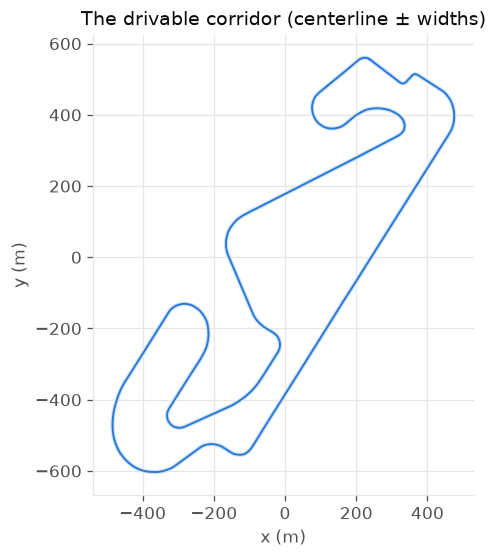

In [2]:
x, y = ds.x.to_numpy(), ds.y.to_numpy()
wl, wr = ds.width_left.to_numpy(), ds.width_right.to_numpy()

# Road-plane normals from the centerline tangent.
dx, dy = np.gradient(x), np.gradient(y)
norm = np.hypot(dx, dy)
nx, ny = -dy / norm, dx / norm

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.fill(np.concatenate([x + nx * wl, (x - nx * wr)[::-1]]),
        np.concatenate([y + ny * wl, (y - ny * wr)[::-1]]),
        color="#cde2fb", lw=0)
ax.plot(x, y, color=BLUE, lw=1.2)
ax.set_aspect("equal")
ax.set_title("The drivable corridor (centerline ± widths)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.show()

## What the ribbon answers along `s`

Curvature `κ_h` sets cornering speed; grade and vertical curvature `κ_v` change the normal
load (a crest unloads the car, a compression loads it — the solver feels both); banking tilts
the grip vector. All of it is one spline query away.

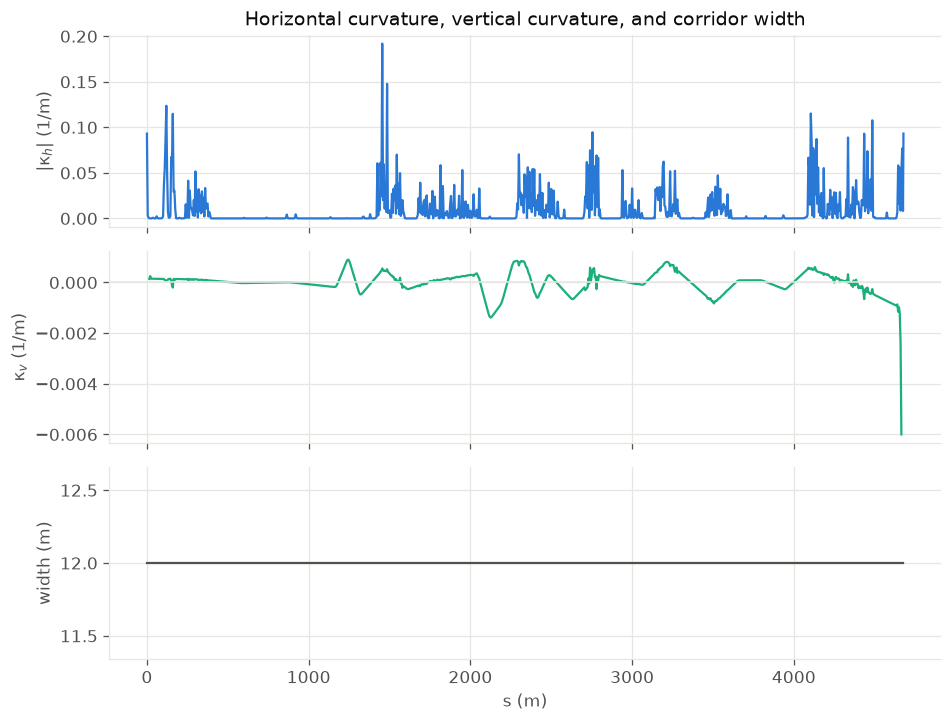

In [3]:
s = ds.s.to_numpy()
interior = slice(3, -3)

fig, axes = plt.subplots(3, 1, figsize=(8.4, 6.4), sharex=True)
axes[0].plot(s, np.abs(ds.kappa_h.to_numpy()), color=BLUE, lw=1.4)
axes[0].set_ylabel("|κ$_h$| (1/m)")
axes[0].set_title("Horizontal curvature, vertical curvature, and corridor width")
axes[1].plot(s[interior], ds.kappa_v.to_numpy()[interior], color=AQUA, lw=1.4)
axes[1].axhline(0, color=GRID, lw=1)
axes[1].set_ylabel("κ$_v$ (1/m)")
axes[2].plot(s, wl + wr, color=INK2, lw=1.4)
axes[2].set_ylabel("width (m)")
axes[2].set_xlabel("s (m)")
plt.tight_layout()
plt.show()

## A circuit built on a hillside: Spa-Francorchamps

Everything above ran on Catalunya, whose relief is modest. The same importer pipeline produces
**`spa_osm`** — Spa-Francorchamps, the classic argument for why elevation belongs in a lap
simulator: the road climbs about **100 m** from Eau Rouge up through Raidillon to Les Combes,
then falls all the way back. That climb is not scenery. Grade tilts the gravity vector the car
accelerates against, and vertical curvature `κ_v` is a live normal-load term: the compression
at the bottom of Eau Rouge *presses* the car into the road (more grip, `κ_v > 0`), and the
crest over Raidillon *unloads* it (less grip, `κ_v < 0`) — exactly the physics of the previous
section, at full scale.


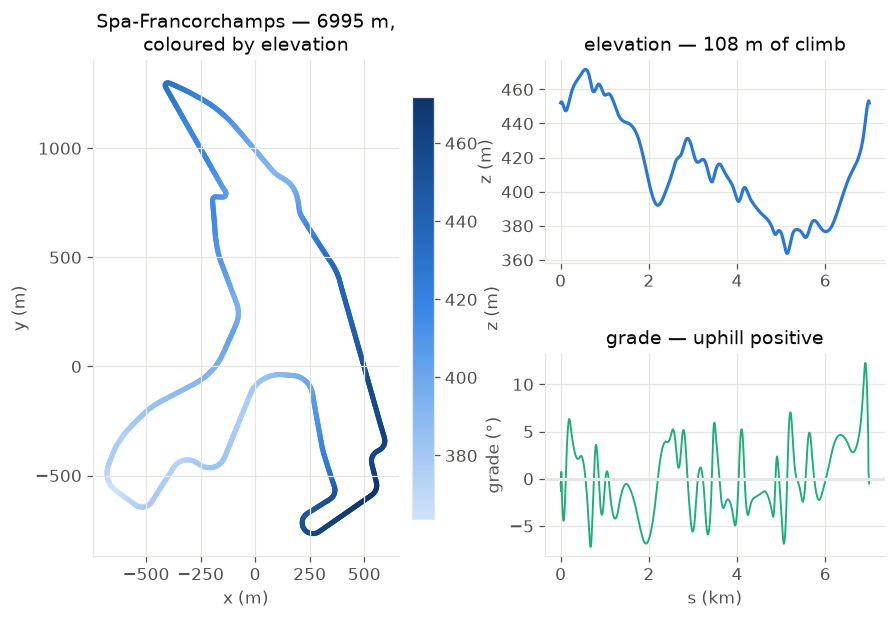

length 6995 m · elevation span 107.9 m · max grade 12.3°


In [4]:
spa = Track.load(str(ROOT / "data" / "tracks" / "spa_osm"))
sds = track_dataset(spa, ds_m=5.0)
sx, sy, sz = sds.x.to_numpy(), sds.y.to_numpy(), sds.z.to_numpy()
ss, sgrade = sds.s.to_numpy(), np.degrees(sds.grade.to_numpy())

fig = plt.figure(figsize=(10.2, 5.6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.35, 1], hspace=0.45, wspace=0.28)

ax = fig.add_subplot(gs[:, 0])
pts = ax.scatter(sx, sy, c=sz, s=5, cmap=SEQ)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Spa-Francorchamps — {spa.length():.0f} m,\ncoloured by elevation")
fig.colorbar(pts, ax=ax, label="z (m)", fraction=0.046, pad=0.03)

az = fig.add_subplot(gs[0, 1])
az.plot(ss / 1e3, sz, color=BLUE)
az.set_ylabel("z (m)")
az.set_title(f"elevation — {sz.max() - sz.min():.0f} m of climb")

ag = fig.add_subplot(gs[1, 1], sharex=az)
ag.plot(ss / 1e3, sgrade, color=AQUA, linewidth=1.2)
ag.axhline(0.0, color=GRID)
ag.set_xlabel("s (km)")
ag.set_ylabel("grade (°)")
ag.set_title("grade — uphill positive")
plt.show()

print(f"length {spa.length():.0f} m · elevation span {sz.max() - sz.min():.1f} m · "
      f"max grade {np.abs(sgrade).max():.1f}°")


## The three tightest corners

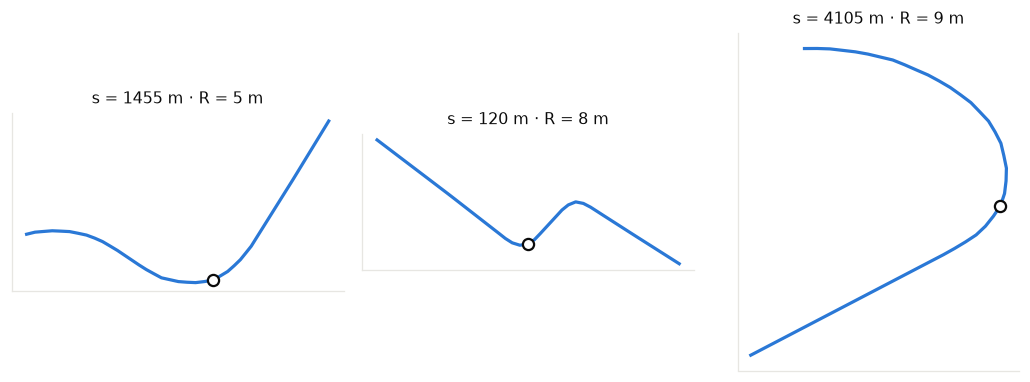

In [5]:
kap = np.abs(ds.kappa_h.to_numpy())
order = np.argsort(kap)[::-1]
picks, used = [], []
for i in order:  # greedy pick, 150 m apart
    if all(abs(s[i] - s[j]) > 150 for j in used):
        picks.append(i)
        used.append(i)
    if len(picks) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
for ax, i in zip(axes, picks):
    win = (s > s[i] - 120) & (s < s[i] + 120)
    ax.plot(x[win], y[win], color=BLUE)
    ax.plot(x[i], y[i], "o", ms=7, mfc="white", mec=INK, mew=1.4)
    ax.set_aspect("equal")
    ax.set_title(f"s = {s[i]:.0f} m · R = {1 / kap[i]:.0f} m", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

> **▶ Interactive.** The next cell is live only in a running Jupyter (`uv sync --group notebooks`,
> then `uv run --with jupyterlab jupyter lab`). On GitHub you're seeing its static twin above.

interactive(children=(FloatSlider(value=1000.0, description='s (m)', max=4677.752047233171, step=25.0), Output…

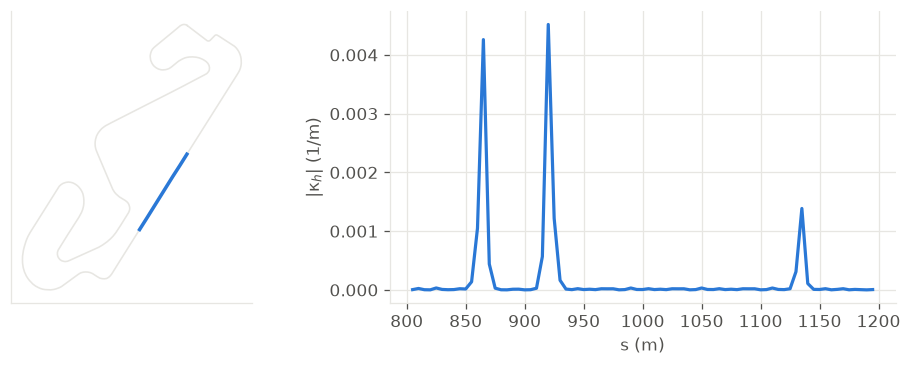

In [6]:
if HAVE_WIDGETS:
    L = float(ds.attrs["length_m"])

    @widgets.interact(s_mid=widgets.FloatSlider(min=0, max=L, step=25, value=1000,
                                                description="s (m)"))
    def corner_explorer(s_mid: float) -> None:
        win = (s > s_mid - 200) & (s < s_mid + 200)
        fig, (a, b) = plt.subplots(1, 2, figsize=(8.6, 3.3),
                                   gridspec_kw={"width_ratios": [1, 1.4]})
        a.plot(x, y, color=GRID, lw=1)
        a.plot(x[win], y[win], color=BLUE, lw=2.2)
        a.set_aspect("equal")
        a.set_xticks([]); a.set_yticks([])
        b.plot(s[win], np.abs(ds.kappa_h.to_numpy())[win], color=BLUE)
        b.set_xlabel("s (m)"); b.set_ylabel("|κ$_h$| (1/m)")
        plt.tight_layout(); plt.show()

    corner_explorer(1000.0)  # direct call: a real error here must fail CI

**Next:** [03 · the racing line](03_raceline.ipynb) — turning the corridor into speed.